In [1]:
import pandas as pd
import os
from datetime import datetime, timedelta

%pip install python-dateutil

from dateutil import parser
import numpy as np

Note: you may need to restart the kernel to use updated packages.


## Compile Dataset Methods

In [2]:
date_time_format = "%m-%d-%Y %H:%M"
compiled_dates = {}

## Remove Extra Columns from Preprocessed Data

In [3]:
def remove_carb_input_and_calories_column(file_path, file_name, output_directory):
    """
    Removes the carb_Input column from all CSV files in the specified directory and 
    saves the modified files to the output directory.
    
    Input:
        directory_path - path of the directory where the CSV files are located
        output_directory - path where the modified files will be saved
    Return: None
    """
    # Ensure the output directory exists
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
    
    # Loop through each file in the directory
    if file_path.endswith(".csv"):
        # Load file data
        df = pd.read_csv(file_path)
            
        # Remove carb_Input column if it exists
        if 'carb_input' in df.columns:
            df = df.drop(columns=['carb_input'])

        glucose = df.pop('glucose')
        df.insert(df.shape[1], glucose.name, glucose)
            
        # Save the modified file to the output directory
        output_file_path = os.path.join(output_directory, file_name)
        df.to_csv(output_file_path, index=False)
    
    # print(f"All files processed. Modified files saved to {output_directory}")

## Alter Files Based on the Days Accounted for In Each Preprocessed File

In [4]:
"""
Check to see if inputted dataset has more than 14 days by parsing data/time column in files

    Input: 
        filePath - path of the directory where the original csv files are
        fileName - name of file being observed
    Return: fileName param, boolean, List
    boolean representing if number of days greater than 14 days and list of days that
    need to be removed

    ##To Do: Add Tuple of Start and End Times found in the file
"""
def isFourteenDays(filePath, fileName):
    # Load data
    filePath = os.path.join(filePath, fileName)
    df = pd.read_csv(filePath)

    # Parse the date column (assuming it's named 'Date'). Adjust if the name is different.
    times = pd.to_datetime(df['time'])
    
    # Calculate date range
    min_date = times.min()
    max_date = times.max()
    days_difference = (max_date - min_date).days
    
    # Identify extra dates beyond the 14-day range
    if days_difference > 14:
        cutoff_date = min_date + timedelta(days=14)
        extra_days = df[times > cutoff_date]['time'].unique().tolist()
        return filePath, True, extra_days, (min_date, max_date)
    else:
        for i in range(len(df['time'])):
            curr_time = df.loc[i, "time"]
            try:
                # Check if the string is already in the desired format
                if datetime.strptime(curr_time, date_time_format):
                    continue  # It's already in the correct format
            except ValueError:
                # Parse and reformat the time if not in the correct format
                try:
                    parsed_time = parser.parse(curr_time)
                    df.loc[i, "time"] = parsed_time.strftime(date_time_format)
                except Exception as e:
                    return f"Error: {curr_time} - {e}"
        df.to_csv(filePath, index=False)
        return filePath, False, [], (min_date, max_date)
    

"""
Using the method above, create a new file that will have the extra days removed from the set
    Input: orgDir, fileName, removeDays, newdirectory
        fileName - name of file beign observed
        removeDays - List of days that need to be removed
        newdirectory - the directory path where the new file will be stored
    Return: None

    ##To Do: Alter the End Time in the tuple from is Fourteen Days
"""
def removeExtraDays(filePath, fileName, removeDays, newdirectory):
    # Load the data
    df = pd.read_csv(filePath)
    
    # Convert date column to datetime format for comparison
    times = pd.to_datetime(df['time'])
    
    # Remove the specified days from the dataset
    df_filtered = df[~times.isin(pd.to_datetime(removeDays))]
    
    # Ensure the output directory exists
    if not os.path.exists(newdirectory):
        os.makedirs(newdirectory)
    
    # Save the filtered file in the new directory
    new_file_path = os.path.join(newdirectory, f"{os.path.basename(fileName)}")
    for i in range(len(df_filtered['time'])):
        curr_time = df_filtered.loc[i, "time"]
        try:
            # Check if the string is already in the desired format
            if datetime.strptime(curr_time, date_time_format):
                continue  # It's already in the correct format
        except ValueError:
            # Parse and reformat the time if not in the correct format
            try:
                parsed_time = parser.parse(curr_time)
                df_filtered.loc[i, "time"] = parsed_time.strftime(date_time_format)
            except Exception as e:
                return f"Error: {curr_time} - {e}"
    df_filtered.to_csv(new_file_path, index=False)


# """
# To Do:
# Compare the intial and final time from each of the remaining time blocks
# Only consider the time and not the day
# If the start times are different from each other choose the later time
# If the end times are different from each other choose the earlier time
# Use the files that was created after removing the extra days

# Use final tuple list from above function
# """
# def alterTimeSteps(filePath, fileName, newDirectory):
#     # Load the data
#     df = pd.read_csv(filePath)
    
#     # Convert 'time' column to datetime
#     df['time'] = pd.to_datetime(df['time'])

#     # Extract only the time
#     df['only_time'] = df['time'].dt.time
    
#     # Find the start and end time
#     new_start_time = df['only_time'].min()
#     new_end_time = df['only_time'].max()

#     df = df[df['only_time'] >= new_start_time]
#     df = df[df['only_time'] <= new_end_time]

#     # Filter dataset to only include rows within the time window
#     df = df[(df['only_time'] >= new_start_time) & (df['only_time'] <= new_end_time)]

#     # Reconstruct full datetime using the original date and adjusted time
#     df['time'] = df['time'].dt.date.astype(str) + " " + df['only_time'].astype(str)
#     df['time'] = pd.to_datetime(df['time'])

#     # Drop temporary column
#     df.drop(columns=['only_time'], inplace=True)

#     # Ensure the output directory exists
#     if not os.path.exists(newDirectory):
#         os.makedirs(newDirectory)

#     # Save the modified file
#     new_file_path = os.path.join(newDirectory, os.path.basename(fileName))
#     df.to_csv(new_file_path, index=False)

#     return filePath, (new_start_time, new_end_time)

"""
Using the files in the directory, concat files into a new dataset. Save the new dataset inside
of the new directory
Make sure to add a new column that represents the patient ID before concatting files
    Input: oldDirectory, newDirectory
        oldDirectory - the directory path where the preprocessing dats is compiled
        newDirectory - the directory path where the concatted data will be stored
    oldDirectory and newDirectory are not going to be same so files will be easily differentiable
    Return: None
"""
##This method needs to be debugged. We may not need to oldDirectory parameter if we add the files
## that have at most 14 days into the new directory in isFouteenDays possibly
def concatFiles(oldDirectory, newDirectory):
    all_data = []
    patient_id = 1
    
    # Loop through each file in the old directory
    for file in os.listdir(oldDirectory):
        if file.endswith(".csv"):
            file_path = os.path.join(oldDirectory, file)
            
            # Load file data
            df = pd.read_csv(file_path)
            
            # Add PatientID column
            df['PatientID'] = patient_id
            all_data.append(df)
            
            # Increment PatientID for the next file
            patient_id += 1
    
    # Concatenate all dataframes in the list
    concatenated_df = pd.concat(all_data, ignore_index=True)

    firstcol = concatenated_df.pop('PatientID')
    concatenated_df.insert(0, 'PatientID', firstcol)

    # Ensure the output directory exists
    if not os.path.exists(newDirectory):
        os.makedirs(newDirectory)
    
    # Save the concatenated dataframe
    output_file = os.path.join(newDirectory, "concatenated_data.csv")
    concatenated_df.to_csv(output_file, index=False)

In [5]:
##Find List of Dates to find in the Raw Data Folder for the associated Patient Id
def getListOfDays(filePath):
    df = pd.read_csv(filePath)
    all_steps = df['time']
    all_steps = all_steps.to_numpy()
    dates = []
    for curr_step in all_steps:
        date_time_obj = datetime.strptime(curr_step, date_time_format)
        curr_date = date_time_obj.date()
        curr_date = curr_date.strftime("%Y-%m-%d")
        if curr_date not in dates:
            dates.append(curr_date)
    return dates

In [6]:
def delete_files_in_directory(directory_path):
   try:
     files = os.listdir(directory_path)
     for file in files:
       file_path = os.path.join(directory_path, file)
       if os.path.isfile(file_path):
         os.remove(file_path)
     print("All files deleted successfully.")
   except OSError:
     print("Error occurred while deleting files.")

## TESTING

In [7]:
##Getting original directory from preprocessing data
orgDataDir = os.path.join(os.getcwd(), "HUPA-UCM Diabetes Dataset")
orgDataDir = os.path.join(orgDataDir, 'Preprocessed')

print(orgDataDir)

##Getting the list of files within the directory
fileList = os.listdir(orgDataDir)
print(fileList)

##Getting the path of the directory where the new files will be stored
concatDataDir = os.path.join(os.getcwd(), "Final_Dataset")
filteredDataDir = os.path.join(concatDataDir, "Filtered_Data")
print(concatDataDir)
print(filteredDataDir)

c:\Users\nwalr\OneDrive - Georgia Institute of Technology\VIP\TreatmentSystems\HUPA-UCM Diabetes Dataset\Preprocessed
['HUPA0001P.csv', 'HUPA0002P.csv', 'HUPA0003P.csv', 'HUPA0004P.csv', 'HUPA0005P.csv', 'HUPA0006P.csv', 'HUPA0007P.csv', 'HUPA0009P.csv', 'HUPA0010P.csv', 'HUPA0011P.csv', 'HUPA0014P.csv', 'HUPA0015P.csv', 'HUPA0016P.csv', 'HUPA0017P.csv', 'HUPA0018P.csv', 'HUPA0019P.csv', 'HUPA0020P.csv', 'HUPA0021P.csv', 'HUPA0022P.csv', 'HUPA0023P.csv', 'HUPA0024P.csv', 'HUPA0025P.csv', 'HUPA0026P.csv', 'HUPA0027P.csv', 'HUPA0028P.csv']
c:\Users\nwalr\OneDrive - Georgia Institute of Technology\VIP\TreatmentSystems\Final_Dataset
c:\Users\nwalr\OneDrive - Georgia Institute of Technology\VIP\TreatmentSystems\Final_Dataset\Filtered_Data


#### Check files that have less than or equal to 14 dates

##### Need to test isFourteenDays()

In [8]:
# # ##Get the path of the file that needs to be opened
# file1_name = "HUPA0010P.csv"
# file_path1 = os.path.join(orgDataDir, file1_name)
# # ##Check to see whether this is 14 days worth of data
# fileName, isfourteen, extraDaysList = isFourteenDays(file_path1, file1_name, filteredDataDir)
# print("File Observed", fileName)
# print("Does Dataset Contain Fourteen Days: ", isfourteen)
# print("Extra Days", extraDaysList)

# getListOfDays(file_path1)

#### Check files that have greater than 14 dates
##### Test the functions isFourteenDays() and removeExtraDays()

In [9]:
# file2_name = 'HUPA0027P.csv'
# file_path2 = os.path.join(orgDataDir, file2_name)
# fileName, isfourteen, extraDaysList = isFourteenDays(file_path2, file2_name, filteredDataDir)
# print("##Check if 14 Days##")
# print("File Observed", fileName)
# print("Does Dataset Contain Fourteen Days: ", isfourteen)
# print("Extra Days", extraDaysList, "\n")


# print("##Remove Days Test##")
# removeExtraDays(file_path2, file2_name, extraDaysList, filteredDataDir)

# filteredData2 = os.path.join(filteredDataDir, file2_name)
# fileName, isfourteen, extraDaysList = isFourteenDays(filteredData2, file2_name, filteredDataDir)
# print("##Check if New File is 14 Days##")
# print("File Observed", fileName)
# print("Does Dataset Contain Fourteen Days: ", isfourteen)
# print("Extra Days", extraDaysList, "\n")

#### Check if concatenation works properly

In [10]:
# concatFiles(filteredDataDir, concatDataDir)

In [11]:
# delete_files_in_directory(filteredDataDir)
# delete_files_in_directory(concatDataDir)

## TESTING

### Call Methods to Filter Out the Data

In [ ]:
print(os.listdir(orgDataDir))
for file_name in os.listdir(orgDataDir):
    file_path = os.path.join(orgDataDir, file_name)
    remove_carb_input_and_calories_column(file_path, file_name, filteredDataDir)
    fileName, isFourteen, extraDaysList, dateRange = isFourteenDays(filteredDataDir, file_name)
    if isFourteen == True:
        removeExtraDays(file_path, file_name, extraDaysList, filteredDataDir)
    filteredPath = os.path.join(filteredDataDir, file_name)
    dates = getListOfDays(filteredPath)
    compiled_dates[file_name.replace(".csv", "")] = dates

['HUPA0001P.csv', 'HUPA0002P.csv', 'HUPA0003P.csv', 'HUPA0004P.csv', 'HUPA0005P.csv', 'HUPA0006P.csv', 'HUPA0007P.csv', 'HUPA0009P.csv', 'HUPA0010P.csv', 'HUPA0011P.csv', 'HUPA0014P.csv', 'HUPA0015P.csv', 'HUPA0016P.csv', 'HUPA0017P.csv', 'HUPA0018P.csv', 'HUPA0019P.csv', 'HUPA0020P.csv', 'HUPA0021P.csv', 'HUPA0022P.csv', 'HUPA0023P.csv', 'HUPA0024P.csv', 'HUPA0025P.csv', 'HUPA0026P.csv', 'HUPA0027P.csv', 'HUPA0028P.csv']


In [ ]:
compiled_dates

{'HUPA0001P': ['2018-06-13',
  '2018-06-14',
  '2018-06-15',
  '2018-06-16',
  '2018-06-17',
  '2018-06-18',
  '2018-06-19',
  '2018-06-20',
  '2018-06-21',
  '2018-06-22',
  '2018-06-23',
  '2018-06-24',
  '2018-06-25',
  '2018-06-26',
  '2018-06-27'],
 'HUPA0002P': ['2018-06-13',
  '2018-06-14',
  '2018-06-15',
  '2018-06-16',
  '2018-06-17',
  '2018-06-18',
  '2018-06-19',
  '2018-06-20',
  '2018-06-21',
  '2018-06-22',
  '2018-06-23',
  '2018-06-24'],
 'HUPA0003P': ['2018-06-13',
  '2018-06-14',
  '2018-06-15',
  '2018-06-16',
  '2018-06-17',
  '2018-06-18',
  '2018-06-19',
  '2018-06-20',
  '2018-06-21',
  '2018-06-22',
  '2018-06-23',
  '2018-06-24',
  '2018-06-25',
  '2018-06-26'],
 'HUPA0004P': ['2018-07-09',
  '2018-07-10',
  '2018-07-11',
  '2018-07-12',
  '2018-07-13',
  '2018-07-14',
  '2018-07-15',
  '2018-07-16',
  '2018-07-17',
  '2018-07-18',
  '2018-07-19',
  '2018-07-20'],
 'HUPA0005P': ['2018-07-09',
  '2018-07-10',
  '2018-07-11',
  '2018-07-12',
  '2018-07-13',
  '

## Concatenating All Filtered Data

In [ ]:
# concatFiles(filteredDataDir, concatDataDir)

In [ ]:
print(np.pi)
print(np.sin(np.pi))
print(f"Month {6}: sin = {np.sin(np.pi):.10f}, cos = {np.cos(np.pi):.10f}")

3.141592653589793
1.2246467991473532e-16
Month 6: sin = 0.0000000000, cos = -1.0000000000


In [ ]:
##Convert TimeStamp to Numerical Values for Training by using Cyclical Encoding
##Uses sine and cosine transformations for timestamp conversions -> creates 6 new features
for file in os.listdir(filteredDataDir):
    concatDataFile = os.path.join(filteredDataDir, file)
    data = pd.read_csv(concatDataFile)
    date_time = pd.to_datetime(data['time'])

    day_of_year = date_time.dt.dayofyear
    month = date_time.dt.month
    hour = date_time.dt.hour
    minute = date_time.dt.minute
    time_of_day = hour + (minute / 60)  # Fractional hour

    data["day_sin"] = np.round(np.sin((2 * np.pi * day_of_year) / 365), 10)
    data["day_cos"] = np.round(np.cos((2 * np.pi * day_of_year) / 365), 10)

    data["day_sin"] = np.where(data['day_sin'] == -0.0, 0.0, data['day_sin'])
    data["day_cos"] = np.where(data['day_cos'] == -0.0, 0.0, data['day_cos'])

    data["month_sin"] = np.round(np.sin((2 * np.pi * month) / 12), 10)
    data["month_cos"] = np.round(np.cos((2 * np.pi * month) / 12), 10)
    
    data["month_sin"] = np.where(data['month_sin'] == -0.0, 0.0, data['month_sin'])
    data["month_cos"] = np.where(data['month_cos'] == -0.0, 0.0, data['month_cos'])

    data['time_sin'] = np.round(np.sin((2 * np.pi * time_of_day) / 24), 10)
    data['time_cos'] = np.round(np.cos((2 * np.pi * time_of_day) / 24), 10)

    data["time_sin"] = np.where(data['time_sin'] == -0.0, 0.0, data['time_sin'])
    data["time_cos"] = np.where(data['time_cos'] == -0.0, 0.0, data['time_cos'])

    col1, col2, col3, col4, col5, col6 = (data.pop('day_sin'), data.pop('day_cos'), 
                                          data.pop('month_sin'), data.pop('month_cos'), 
                                          data.pop('time_sin'), data.pop('time_cos'))
    data.insert(1, col1.name, col1)
    data.insert(2, col2.name, col2)
    data.insert(3, col3.name, col3)
    data.insert(4, col4.name, col4)
    data.insert(5, col5.name, col5)
    data.insert(6, col6.name, col6)
    data.to_csv(concatDataFile, index = False)

In [ ]:
# data.pop('time_of_day')
# data.to_csv(concatDataFile, index = False)

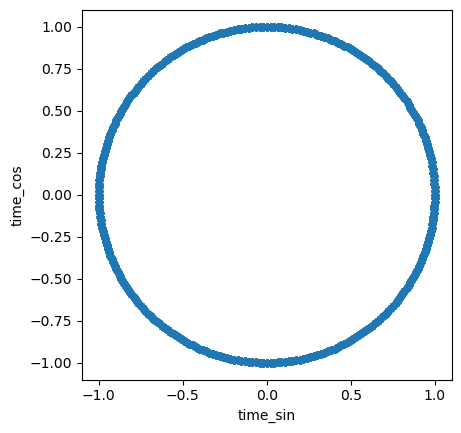

In [ ]:
data.plot.scatter('time_sin', 'time_cos').set_aspect('equal')